In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import pandas as pd
import cf_xarray
import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.lines import Line2D
import seaborn as sns

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from map_plot_tools import *
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *


In [2]:
def wind_sig_mask(diff_mask, key, run):
    """
    Return (u_sig, v_sig) arrays where both wind components are significant.
    """
    both_sig = (diff_mask[key][run]['u925'].mask == False) & \
               (diff_mask[key][run]['v925'].mask == False)
    u_sig = np.where(both_sig, diff_mask[key][run]['u925'].data, np.nan)
    v_sig = np.where(both_sig, diff_mask[key][run]['v925'].data, np.nan)
    return u_sig, v_sig


# LOAD DATA

In [3]:
### +++ DATA PATHS +++ ###

# product keys
keys=['obs','flor']
obs_prods=['merra2']
flor_runs=['ctrl','hicam','hitopo']
flor_simNames=['ctrl','cam','hitopo']

# store file paths in dictionary
dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar' # top level data directory
opath='/home/dmkumar/JupyterLinks/notebooks/topo_heat/figs'
files={ 'obs'  : { prod:{} for prod in obs_prods },
        'flor' : { run: {} for run  in flor_runs } }

for key in ['obs']:
    for prod in obs_prods:
        files[key][prod]['u925'] = f'{dpath0}/obs_data/merra2/merra2.U.1980-2022.monthly.nc' 
        files[key][prod]['v925'] = f'{dpath0}/obs_data/merra2/merra2.V.1980-2022.monthly.nc' 
        files[key][prod]['slp'] = f'{dpath0}/obs_data/merra2/merra2.SLP.1980-2022.monthly.nc' 

for key in ['flor']:
    for i,run in enumerate(flor_runs):
        simName=flor_simNames[i]
        for varn in ['u925','v925','slp']:
            files[key][run][varn] = f'{dpath0}/FLOR/{run}/pi/flor.{simName}.{varn}.monthly.nc' 

for key in ['topo']:
    files[key] = {}
    files[key]['etopo'] = f'{dpath0}/topo_files/obs.etopo5.zsurf.nc'
    files[key]['ctrl'] = f'{dpath0}/topo_files/flor.ctrl.zsurf.nc'
    files[key]['hicam'] = f'{dpath0}/topo_files/flor.cam.zsurf.nc'
    files[key]['hitopo'] = f'{dpath0}/topo_files/flor.hitopo.zsurf.nc'

In [4]:
## +++ ORGANIZE DATA +++ ##

#=== Settings
latmin = 10
latmax = 55
lonmin = 215
lonmax = 285
plev = 925 # pressure level
n_years = 50 # model years to keep
n_keep_mons = -1 * (n_years * 12)  # number of model time steps to keep in months

#=== Meteorological variables
dat = { 'obs'  : { prod:{} for prod in obs_prods },
        'flor' : { run: {} for run  in flor_runs } }

# Reanalysis
for key in ['obs']:
    print(f'\n{key}')
    
    for run in obs_prods:
        print(f'->{run}')
        
        for i, ovarn in enumerate(['U', 'V']):
            varn = ['u925', 'v925'][i]
            ds = xr.open_dataset(files[key][run][varn], chunks={'time': 12})[ovarn].sel(lev=plev)
            dat[key][run][varn] = lonFlip(ds)
        ds = xr.open_dataset(files[key][run]['slp'], chunks={'time': 12})['SLP'] / 100
        dat[key][run]['slp'] = lonFlip(ds)
        
        slp_gm = lat_weighted_mean(dat[key][run]['slp'])
        dat[key][run]['slpa'] = dat[key][run]['slp'] - slp_gm

# CM2.5-FLOR model output
for key in ['flor']:
    print(f'\n{key}')
    
    for run in flor_runs:
        print(f'->{run}')

        for varn in ['u925', 'v925', 'slp']:
            ds = xr.open_dataset(files[key][run][varn], chunks={'time': 12})[varn].isel(time=slice(n_keep_mons, None))
            if varn in ['u925', 'v925']:
                ds = ds.rename({'grid_xt': 'lon', 'grid_yt': 'lat'})
            ds['lat'].attrs['units'] = 'degrees_north'
            ds['lon'].attrs['units'] = 'degrees_east'
            dat[key][run][varn] = ds
            
        slp_gm = lat_weighted_mean(dat[key][run]['slp'])
        dat[key][run]['slpa'] = dat[key][run]['slp'] - slp_gm


#=== Topography data
topo = {}

print('topo')
for case,filen in files['topo'].items():
    if case=='etopo':
        ds = xr.open_dataset(files['topo'][case]).ROSE.rename({'ETOPO05_X':'lon', 'ETOPO05_Y':'lat'})
        topo[case] = ds.where(ds>0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        del ds
    elif case in ['ctrl', 'hicam', 'hitopo']:
        ds = xr.open_dataset(files['topo'][case]).ZSURF.rename({'GRID_XT':'lon', 'GRID_YT':'lat'})
        topo[case] = ds.where(ds>0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        del ds

print('\nDone.')

Working on...

obs
->merra2

flor
->ctrl
->hicam
->hitopo

Done.


In [5]:
### +++ CALCULATE TIME-MEANS +++ ###

season = 'JAS'
mons = [7, 8, 9]
varns = ['u925', 'v925', 'slp', 'slpa']

jas_mean     = { 'obs'  : { prod:{} for prod in obs_prods },
                 'flor' : { run: {} for run  in flor_runs } }
ann_jas_mean = { 'obs'  : { prod:{} for prod in obs_prods },
                 'flor' : { run: {} for run  in flor_runs } }

print('Calculating seasonal means for...')
run_map = {'obs': obs_prods, 'flor': flor_runs}
for key, runs in run_map.items():
    print(key)
    for run in runs:
        jas_mask = dat[key][run]['u925']['time'].dt.month.isin(mons)
        for varn in varns:
            ann_jas_mean[key][run][varn] = (
                dat[key][run][varn]
                .sel(time=jas_mask)
                .groupby('time.year')
                .mean(dim='time')
            )
            jas_mean[key][run][varn] = ann_jas_mean[key][run][varn].mean('year')

print('Done.')

Calculating seasonal means for...
obs
flor
Done.


In [6]:
### +++ COMPARING ALL MODEL RUNS TO OBS. +++ ###

#=== Interpolate obs data to model grid
regrid_keys = ['obs_flor']
jas_mean_regrid = { key : {} for key in regrid_keys }
ann_jas_mean_regrid = { key : {} for key in regrid_keys }

print('Re-gridding obs.')
for i,key in enumerate(['flor']):
    lats=dat[key]['ctrl']['spd'].lat
    lons=dat[key]['ctrl']['spd'].lon
    regrid_key=regrid_keys[i]
    for varn in varns:
        jas_mean_regrid[regrid_key][varn] = jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')
        ann_jas_mean_regrid[regrid_key][varn] = ann_jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')
print('Done.\n')


#=== Determine obs-model differences and statistical significance based on students t-test
obs_diff      = { 'flor' : { run: {} for run  in flor_runs } }
obs_diff_mask = { 'flor' : { run: {} for run  in flor_runs } }
obs_ptvals    = { 'flor' : { run: {} for run  in flor_runs } }

print('Significance testing for:')
for key in obs_diff.keys():
    print(f'{key}')
    
    for run in flor_runs:
        print(f'...{run}')
        
        for varn in varns:
            diff_, diff_mask_, ptvals_ = sigtest2n(ann_jas_mean_regrid['obs_flor'][varn], ann_jas_mean[key][run][varn], 
                                                   jas_mean_regrid['obs_flor'][varn], jas_mean[key][run][varn])
            obs_diff[key][run][varn] = diff_
            obs_diff_mask[key][run][varn] = diff_mask_
            obs_ptvals[key][run][varn] = ptvals_
print('Done.\n')


#=== Additionally mask wind components where only both are significant
obs_usig = {'flor': {}}
obs_vsig = {'flor': {}}

for key in obs_usig:
    for run in flor_runs:
        obs_usig[key][run], obs_vsig[key][run] = wind_sig_mask(obs_diff_mask, key, run)
print('Wind component mask created.')

Re-gridding obs.
Done.

Significance testing for:
flor
...ctrl
...hicam
...hitopo
Done.


In [8]:
### +++ COMPARING ALL MODEL RUNS TO MODEL CTRL. +++ ###

#=== Calculate modified_topo_run - ctrl differences and statistical significance based on students t-test
flor_mod_runs = ['hicam', 'hitopo'] # modified topography run names
model_diff      = { 'flor' : { run:{} for run in flor_mod_runs } }
model_diff_mask = { 'flor' : { run:{} for run in flor_mod_runs } }
model_ptvals    = { 'flor' : { run:{} for run in flor_mod_runs } }

print('Significance testing for:')
for key in model_diff.keys():
    print(f'{key}')
    
    for run in flor_mod_runs:
        print(f'...{run}')
        
        for varn in varns:
            diff_, diff_mask_, ptvals_ = sigtest2n(ann_jas_mean[key][run][varn], ann_jas_mean[key]['ctrl'][varn],
                                                   jas_mean[key][run][varn], jas_mean[key]['ctrl'][varn])
            model_diff[key][run][varn] = diff_
            model_diff_mask[key][run][varn] = diff_mask_
            model_ptvals[key][run][varn] = ptvals_

print('Done.\n')


#=== Additionally mask wind components where only both are significant
model_usig = {'flor': {}}
model_vsig = {'flor': {}}

for key in model_usig:
    for run in flor_mod_runs:
        model_usig[key][run], model_vsig[key][run] = wind_sig_mask(model_diff_mask, key, run)

print('Wind component mask created.')

Significance testing for:
flor
...hicam
...hitopo
Done.

Wind component mask created.


In [9]:
### +++ BIAS IMPROVEMENT +++ ###
# calculate difference in the absolute value of the model-obs precip difference
# to determine whether or not the change in precipitation is a reduction in the ctrl model bias

bias_change        = { 'flor' : { run:{} for run in flor_mod_runs } }
bias_change_masked = { 'flor' : { run:{} for run in flor_mod_runs } }

for key in bias_change.keys():
    for run in flor_mod_runs:
        for varn in varns:
            bias_change[key][run][varn] = np.abs(obs_diff[key][run][varn])-np.abs(obs_diff[key]['ctrl'][varn])
            bias_change_masked[key][run][varn] = bias_change[key][run][varn].where(model_diff_mask[key][run][varn].mask==False,np.nan)

# FIGURES

### Maps of climatological slp or slp anomaly and low-level winds

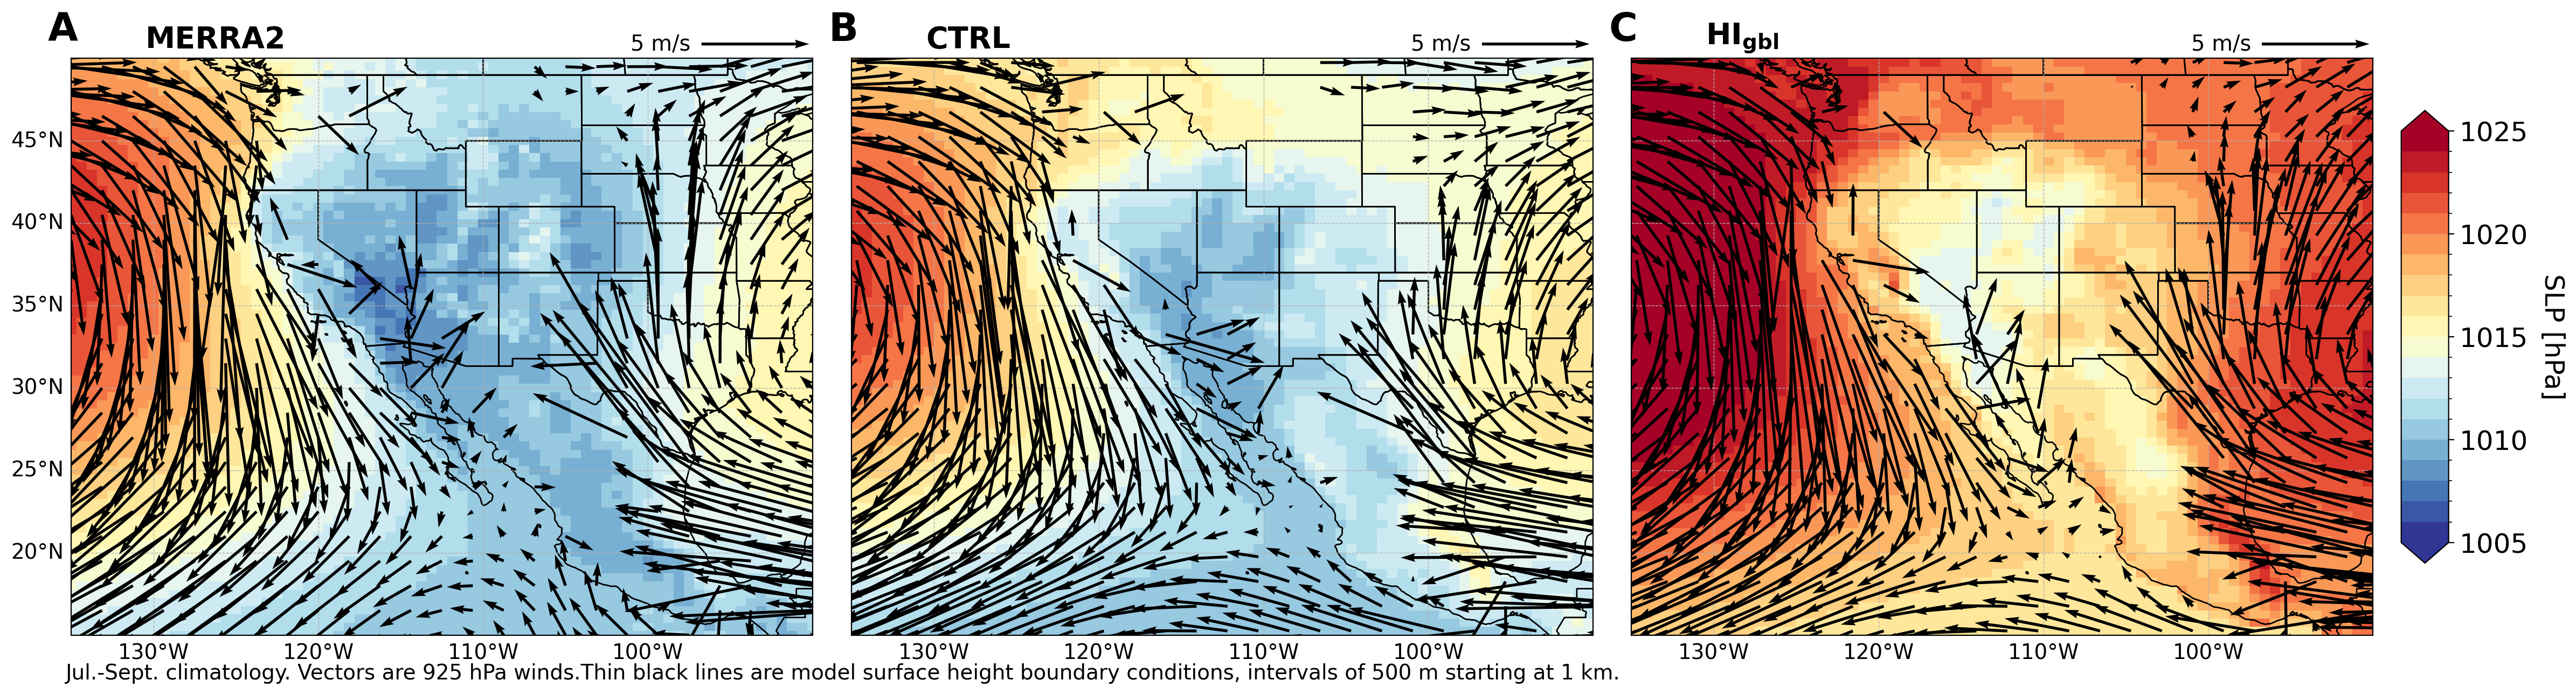

In [19]:
#=== Settings
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'left', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA2', 'CTRL', r'HI$_{\mathbf{gbl}}$'])
letters=['A','B','C']
tx=-130.5
ty=50.25
# var specs
lat=jas_mean['flor']['ctrl']['slp'].lat
lon=jas_mean['flor']['ctrl']['slp'].lon
# vector specs
skip_nh=3
skip_nl=1
w=0.005
scalef=5
key_length=5
# slp colormap
dcmap=cm.RdYlBu_r
dvmin=1005
dvmax=1025
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,270,15,50]
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(22,6), layout='constrained', subplot_kw={'projection':proj})

fig.text(0.025,-0.05,
         'Jul.-Sept. climatology. Vectors are 925 hPa winds.'
         'Thin black lines are model surface height boundary conditions, intervals of 500 m starting at 1 km.',
         **text_kw3)

#=== MERRA-2 ===
cf=ax[0].pcolormesh(jas_mean['obs']['merra2']['slp'].lon, jas_mean['obs']['merra2']['slp'].lat, jas_mean['obs']['merra2']['slp'], cmap=dcmap, norm=dnorm, transform=trans)
# wind vectors
q1=ax[0].quiver(jas_mean['obs']['merra2']['u925'].lon[::skip_nh], jas_mean['obs']['merra2']['u925'].lat[::skip_nh],
                jas_mean['obs']['merra2']['u925'][::skip_nh,::skip_nh], jas_mean['obs']['merra2']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[0].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# topo contours
#ax[0].contour(topo['etopo'].lon, topo['etopo'].lat, topo['etopo'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== CTRL ===
cf=ax[1].pcolormesh(lon, lat, jas_mean['flor']['ctrl']['slp'], cmap=dcmap, norm=dnorm, transform=trans)
# wind vectors
q1=ax[1].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['ctrl']['u925'][::skip_nh,::skip_nh], jas_mean['flor']['ctrl']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[1].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# topo contours
#ax[1].contour(topo['ctrl'].lon, topo['ctrl'].lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== HI-GBL ===
ax[2].pcolormesh(lon, lat, jas_mean['flor']['hitopo']['slp'], cmap=dcmap, norm=dnorm, transform=trans)
# wind vectors
q2=ax[2].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['hitopo']['u925'][::skip_nh,::skip_nh], jas_mean['flor']['hitopo']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[2].quiverkey(q2, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# topo contours
#ax[2].contour(topo['hitopo'].lon, topo['hitopo'].lat, topo['hitopo'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(tx-5, ty+1.5, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=1)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# colorbar
cax=fig.add_axes([1.01, 0.15, 0.02, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(1005,1025,5), orientation='vertical', extend='both', cax=cax)
cbar.set_label('SLP [hPa]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center') 
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

In [ ]:
#=== Settings
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA2', 'CTRL', r'HI$_{\mathbf{gbl}}$'])
letters=['A','B','C']
tx=-130.5
ty=50.25
# var specs
lat=jas_mean['flor']['ctrl']['slp'].lat
lon=jas_mean['flor']['ctrl']['slp'].lon
# vector specs
skip_nh=3
skip_nl=1
w=0.004
scalef=8
key_length=5
# slpa colormap
dcmap=RdBu_r
dvmin=-20
dvmax=20
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,270,15,50]
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(22,6), layout='constrained', subplot_kw={'projection':proj})

fig.text(0.025,0,
         'Thin black lines are model surface height boundary conditions, intervals of 500 m starting at 1 km.',
         **text_kw3)

#=== MERRA-2 ===
cf=ax[0].pcolormesh(jas_mean['obs']['merra2']['slp'].lon, jas_mean['obs']['merra2']['slp'].lat, jas_mean['obs']['merra2']['slp'], cmap=dcmap, norm=dnorm, transform=trans)
# wind vectors
q1=ax[0].quiver(jas_mean['obs']['merra2']['u925'].lon[::skip_nh], jas_mean['obs']['merra2']['u925'].lat[::skip_nh],
                jas_mean['obs']['merra2']['u925'][::skip_nh,::skip_nh], jas_mean['obs']['merra2']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[0].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# topo contours
#ax[0].contour(topo['etopo'].lon, topo['etopo'].lat, topo['etopo'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== CTRL ===
cf=ax[1].pcolormesh(lon, lat, jas_mean['flor']['ctrl']['slp'], cmap=dcmap, norm=dnorm, transform=trans)
# wind vectors
q1=ax[1].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['ctrl']['u925'][::skip_nh,::skip_nh], jas_mean['flor']['ctrl']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[1].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# topo contours
#ax[1].contour(topo['ctrl'].lon, topo['ctrl'].lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== HI-GBL ===
ax[2].pcolormesh(lon, lat, jas_mean['flor']['hitopo']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
# wind vectors
q2=ax[2].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['hitopo']['u925'][::skip_nh,::skip_nh], jas_mean['flor']['hitopo']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[2].quiverkey(q2, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# topo contours
#ax[2].contour(topo['hitopo'].lon, topo['hitopo'].lat, topo['hitopo'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-136, ty+1, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=1)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# colorbar
cax=fig.add_axes([1.01, 0.15, 0.02, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(-20,20,11), orientation='vertical', extend='both', cax=cax)
cbar.set_label('SLP anomaly relative to global mean [hPa]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center') 
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

### Figure 3: CM2.5-FLOR CTRL bias and change in HIgbl and HIcam relative to CTRL for SLP anomaly and 925 hPa winds

#### First, define regions to average Gulf of California Low-Level Jet strength and along-gulf SLP gradient 

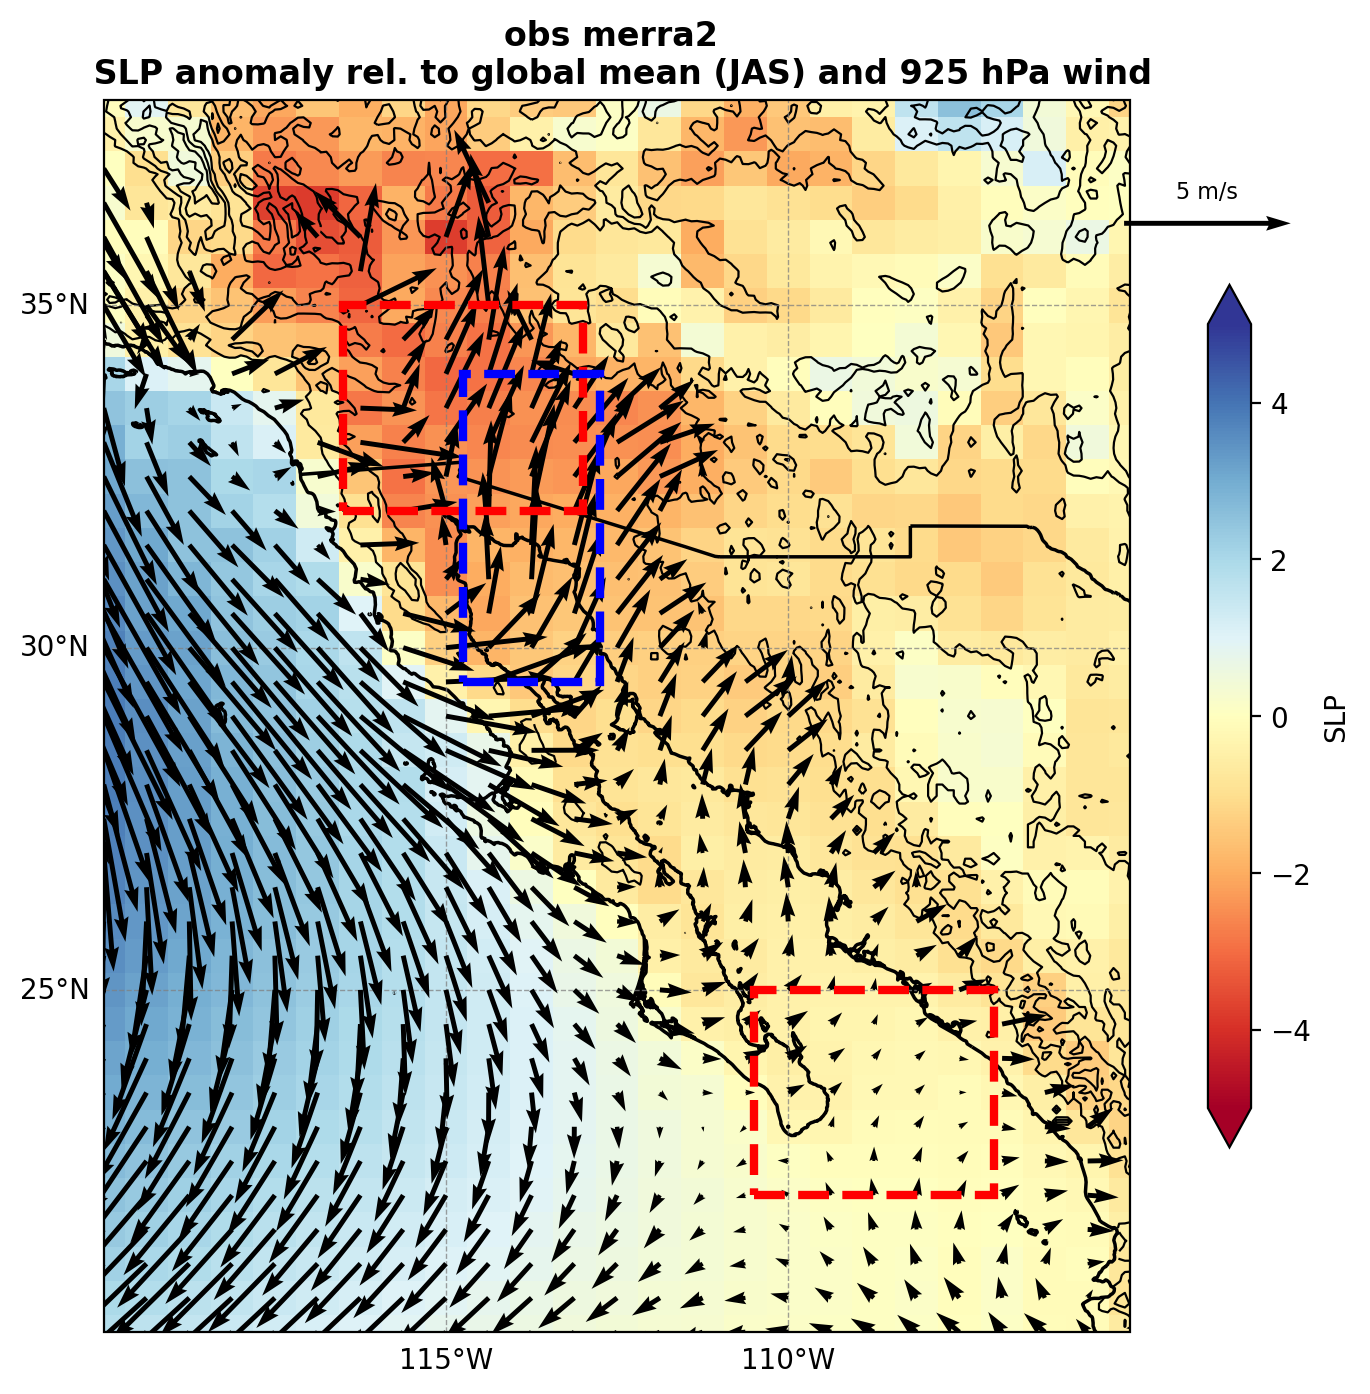

In [20]:
## +++ DETERMINE REGIONS BASED ON MERRA-2 CLIMATOLOGY +++ ##
# vector specs
skip_nh=1
w=0.004
scalef=6
key_length=2
# topography contours
zlevels=np.linspace(800,4000,5)
# init fig
fig = plt.figure(figsize=(10, 8))
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)

# var info
key='obs'
run='merra2'
varn='slpa'
da=jas_mean[key][run][varn]

p = da.plot(
    ax=ax,
    vmin=-5,
    vmax=5,
    transform=ccrs.PlateCarree(),  
    cmap='RdYlBu',               
    cbar_kwargs={'shrink': 0.7, 'label': da.name if hasattr(da, 'name') else ''},
)

# add topography
ax.contour(topo['etopo'].lon, topo['etopo'].lat, topo['etopo'], levels=zlevels, linewidths=0.8, colors='black', transform=trans)

# add wind vectors
q1=ax.quiver(jas_mean['obs']['merra2']['u925'].lon[::skip_nh], jas_mean['obs']['merra2']['u925'].lat[::skip_nh],
             jas_mean['obs']['merra2']['u925'][::skip_nh,::skip_nh], jas_mean['obs']['merra2']['v925'][::skip_nh,::skip_nh],
             color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax.quiverkey(q1, 1.075, .9, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='N', fontproperties={'size':8})

# low-lying deserts box
box=patches.Rectangle( (243.5, 32), 3.5, 3, lw=3, ls='--', ec='r', fc='none', zorder=100, transform=trans); ax.add_patch(box)
# mouth of gulf of california box
box=patches.Rectangle( (249.5, 22), 3.5, 3, lw=3, ls='--', ec='r', fc='none', zorder=100, transform=trans); ax.add_patch(box)
# GoCLLJ box
box=patches.Rectangle( (245.25, 29.5), 2, 4.5, lw=3, ls='--', ec='b', fc='none', zorder=100, transform=trans); ax.add_patch(box)

ax.set_title(f'{key} {run} \n SLP anomaly rel. to global mean (JAS) and 925 hPa wind', fontsize=12, fontweight='bold')

ax.coastlines(linewidth=1.25)
ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax.set_extent([-120, -105, 20, 38], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.75, linestyle='--')
gl.top_labels = False; gl.right_labels = False
gl.xlocator = plt.FixedLocator(range(-180, 181, 5))
gl.ylocator = plt.FixedLocator(range(-90, 91, 5))

In [21]:
slp_dsrt_bnds = [243.5, 247,    32,   35  ]
slp_sgoc_bnds = [249.5, 253,    22,   25  ]
v925_llj_bnds = [245.25, 247.25, 29.5, 34 ]

# slpa and v925 regional means (per-year JAS)
slp_dsrt = {}
slp_sgoc = {}
slp_diff = {}
v_llj    = {}

run_map = {'obs': ['merra2'], 'flor': ['ctrl', 'hicam', 'hitopo']}
for key, run_list in run_map.items():
    for run in run_list:
        slpa_yr = ann_jas_mean[key][run]['slpa']
        v_yr    = ann_jas_mean[key][run]['v925']
        slp_dsrt[run] = slpa_yr.sel(
            lat=slice(slp_dsrt_bnds[2], slp_dsrt_bnds[3]),
            lon=slice(slp_dsrt_bnds[0], slp_dsrt_bnds[1])
        ).mean(dim=['lat', 'lon'])
        slp_sgoc[run] = slpa_yr.sel(
            lat=slice(slp_sgoc_bnds[2], slp_sgoc_bnds[3]),
            lon=slice(slp_sgoc_bnds[0], slp_sgoc_bnds[1])
        ).mean(dim=['lat', 'lon'])
        v_llj[run] = v_yr.sel(
            lat=slice(v925_llj_bnds[2], v925_llj_bnds[3]),
            lon=slice(v925_llj_bnds[0], v925_llj_bnds[1])
        ).mean(dim=['lat', 'lon'])
        slp_diff[run] = slp_sgoc[run] - slp_dsrt[run]

# create dataframes
slp_df = pd.concat(
    {model: da.to_series() for model, da in slp_diff.items()},
    axis=1
)

llj_df = pd.concat(
    {model: da.to_series() for model, da in v_llj.items()},
    axis=1
)


In [ ]:
text_kw={'color':'k', 'weight':'bold', 'size':17, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':23, 'ha':'center', 'va':'center'}
runs = ['MERRA2', 'CTRL', 'HI$_{GBL}$', 'HI$_{MEX}$']
map_titles=['CTRL$-$MERRA2', r'HI$_{\mathbf{GBL}}$$-$CTRL', r'HI$_{\mathbf{MEX}}$$-$CTRL']
bottom_titles = [ 'Along-Gulf SLP Gradient', '925 hPa Meridional Wind', 'SLP Gradient–GoCLLJ Relationship']
letters=['A','B','C','D','E','F']
tx=-110.5
ty=40.25
# var specs
lat=jas_mean['flor']['ctrl']['slp'].lat
lon=jas_mean['flor']['ctrl']['slp'].lon
# vector specs
skip_nh=3
skip_nl=1
w=0.006
scalef=2
key_length=1
# distribution colors
colors = ['black','lightsteelblue','darkred','peru']
# bias colormap
dcmap=cm.coolwarm_r #RdBu_r
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]


fig = plt.figure(figsize=(20, 12), constrained_layout=True)
gs = gridspec.GridSpec(nrows=2, ncols=3, height_ratios=[2.2, 1], figure=fig)
# define axes explicitly
ax_map = [
    fig.add_subplot(gs[0, 0], projection=proj),
    fig.add_subplot(gs[0, 1], projection=proj),
    fig.add_subplot(gs[0, 2], projection=proj),
]
ax_kde_slp = fig.add_subplot(gs[1, 0])
ax_kde_llj = fig.add_subplot(gs[1, 1])
ax_scatter = fig.add_subplot(gs[1, 2])


#=== CTRL ===
ax = ax_map[0]
cf=ax.pcolormesh(lon, lat, obs_diff_mask['flor']['ctrl']['slpa']*-1, cmap=dcmap, norm=dnorm, transform=trans) # flip sign so it reflects CTRL-MERRA2
q1=ax.quiver(lon[::skip_nh], lat[::skip_nh],
                obs_usig['flor']['ctrl'][::skip_nh,::skip_nh], obs_vsig['flor']['ctrl'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
ax.contour(topo['ctrl'].lon, topo['ctrl'].lat, topo['ctrl'], levels=zlevels, linewidths=2, colors='black', transform=trans)

#=== HI-GBL ===
ax = ax_map[1]
ax.pcolormesh(lon, lat, model_diff_mask['flor']['hitopo']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
q2=ax.quiver(lon[::skip_nh], lat[::skip_nh],
                model_usig['flor']['hitopo'].squeeze()[::skip_nh,::skip_nh], model_vsig['flor']['hitopo'].squeeze()[::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax.quiverkey(q2, 1.1, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
#ax.contourf(lon, lat, bias_change_masked['flor']['hitopo']['slpa'],
#               0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)
ax.contour(topo['hitopo'].lon, topo['hitopo'].lat, topo['hitopo'], levels=zlevels, linewidths=2, colors='black', transform=trans)
# low-lying deserts box
box=patches.Rectangle( (243.5, 32), 3.5, 3, lw=3, ls='--', ec='r', fc='none', zorder=100, transform=trans); ax.add_patch(box)
# mouth of gulf of california box
box=patches.Rectangle( (249.5, 22), 3.5, 3, lw=3, ls='--', ec='r', fc='none', zorder=100, transform=trans); ax.add_patch(box)
# GoCLLJ box
box=patches.Rectangle( (245.25, 29.5), 2, 4.5, lw=3, ls=':', ec='orange', fc='none', zorder=100, transform=trans); ax.add_patch(box)

#=== HI-MEX ===
ax = ax_map[2]
ax.pcolormesh(lon, lat, model_diff_mask['flor']['hicam']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
q2=ax.quiver(lon[::skip_nh], lat[::skip_nh],
                model_usig['flor']['hicam'].squeeze()[::skip_nh,::skip_nh], model_vsig['flor']['hicam'].squeeze()[::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
#ax.contourf(lon, lat, bias_change_masked['flor']['hicam']['slpa'],
#               0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)
ax.contour(topo['hicam'].lon, topo['hicam'].lat, topo['hicam'], levels=zlevels, linewidths=2, colors='black', transform=trans)

for i, ax in enumerate(ax_map): 
    # subplot labels
    ax.text(tx, ty, map_titles[i], **text_kw)
    ax.text(-121, ty+0.5, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=.75)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=.75)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=.75)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.left_labels = (i == 0); gl.bottom_labels = True; gl.top_labels = False; gl.right_labels = False
    gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

#=== SLP KDE ===
for col, c in zip(slp_df.columns, colors):
    vals = slp_df[col].dropna()
    sns.kdeplot(
        data=vals,
        ax=ax_kde_slp,
        fill=True,
        color=c,
        label=col
    )
    ax_kde_slp.axvline(vals.mean(), color=c, lw=2)
    ax_kde_slp.axvline(vals.median(), color=c, lw=2, ls='--')
ax_kde_slp.set_xlabel('Relative SLP Difference [hPa]', fontsize=14)
ax_kde_slp.set_ylabel('Density', fontsize=14)
ax_kde_slp.set_xlim([-4, 8])
ax_kde_slp.set_title('D', loc='left', **text_kw2)

#=== LLJ KDE ===
for col, c in zip(llj_df.columns, colors):
    vals = llj_df[col].dropna()
    sns.kdeplot(
        data=vals,
        ax=ax_kde_llj,
        fill=True,
        color=c,
        label=col
    )
    ax_kde_llj.axvline(vals.mean(), color=c, lw=2)
    ax_kde_llj.axvline(vals.median(), color=c, lw=2, ls='--')
ax_kde_llj.set_xlabel('$V$-Wind Magnitude [m/s]', fontsize=14)
ax_kde_llj.set_ylabel('')
ax_kde_llj.set_title('E', loc='left', **text_kw2)

stat_handles = [
    Line2D([0], [0], color='k', lw=2, ls='-',  label='Mean'),
    Line2D([0], [0], color='k', lw=2, ls='--', label='Median'),
]
ax_kde_slp.legend(
    handles=stat_handles,
    loc='upper right',
    frameon=False,
    fontsize=12
)

#=== SLP-LLJ Scatter ===
for i, run in enumerate(['merra2','ctrl','hitopo','hicam']):
    x = slp_diff[run]
    y = v_llj[run]
    ax_scatter.scatter(
        x,y,
        100,
        ec='k',
        fc=colors[i],
        alpha=0.65,
        label=run
    )
    # linear trend
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax_scatter.plot(
        xx,
        m * xx + b,
        color=colors[i],
        lw=3
    )
ax_scatter.set_xlabel('Relative SLP Difference [hPa]', fontsize=14)
ax_scatter.set_ylabel('925 hPa V-Wind Magnitude [m/s]', fontsize=14)
ax_scatter.set_title('F', loc='left', **text_kw2)

for ax, title in zip([ax_kde_slp, ax_kde_llj, ax_scatter], bottom_titles):
    ax.text(0.5, 1.01, title, transform=ax.transAxes, **text_kw)
for ax in [ax_kde_slp, ax_kde_llj, ax_scatter]:
    ax.tick_params(which='major', labelsize=14)

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=c,
        markeredgecolor='k',
        markersize=10,
        label=run
    )
    for run, c in zip(runs, colors)
]
fig.legend(handles=legend_handles, handletextpad=0.4, loc='center right', ncol=1, frameon=False, fontsize=14, bbox_to_anchor=(1.25, 0.5), bbox_transform=ax_scatter.transAxes)

# colorbar
cax=fig.add_axes([1.01, 0.4, 0.02, 0.55])
cbar=fig.colorbar(cf, ticks=np.linspace(-10,10,21), orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$ Relative SLP [hPa]', labelpad=25, rotation=270, size=16, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=16)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'figs/slpa.925wind.change.flor.{season}.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(f'figs/slpa.925wind.change.flor.{season}.png', transparent=False, bbox_inches='tight')